In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


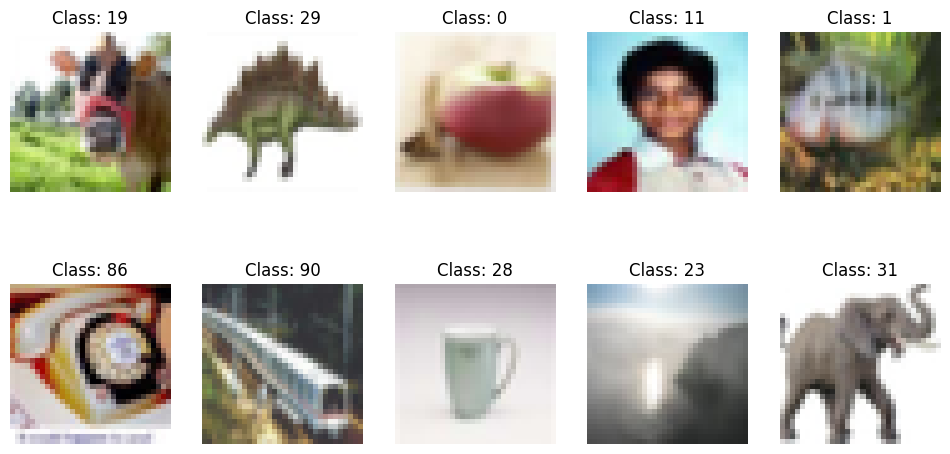

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(f"Class: {y_train[i][0]}")
    plt.axis('off')

plt.show()

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train, 100)
y_test = to_categorical(y_test, 100)

print(y_train.shape)
print(y_test.shape)

(50000, 100)
(10000, 100)


In [ ]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3),
                 activation='relu',
                 padding='same',
                 input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3),
                 activation='relu',
                 padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3),
                 activation='relu',
                 padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(256, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,388 (2.46 MB)

 Trainable params: 643,940 (2.46 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.0624 - loss: 4.2727 - val_accuracy: 0.1378 - val_loss: 3.7157
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1214 - loss: 3.7540 - val_accuracy: 0.1905 - val_loss: 3.4153
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1614 - loss: 3.4841 - val_accuracy: 0.2377 - val_loss: 3.1443
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1984 - loss: 3.2832 - val_accuracy: 0.2650 - val_loss: 2.9775
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2312 - loss: 3.0799 - val_accuracy: 0.2940 - val_loss: 2.8078
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2585 - loss: 2.9214 - val_accuracy: 0.2496 - val_loss: 3.0986
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2899 - loss: 2.7607 - val_accuracy: 0.3371 - val_loss: 2.6135
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3215 - loss: 2.6254 - val_accuracy: 

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4262 - loss: 2.4094
Test Loss: 2.409374237060547
Test Accuracy: 0.4262000024318695


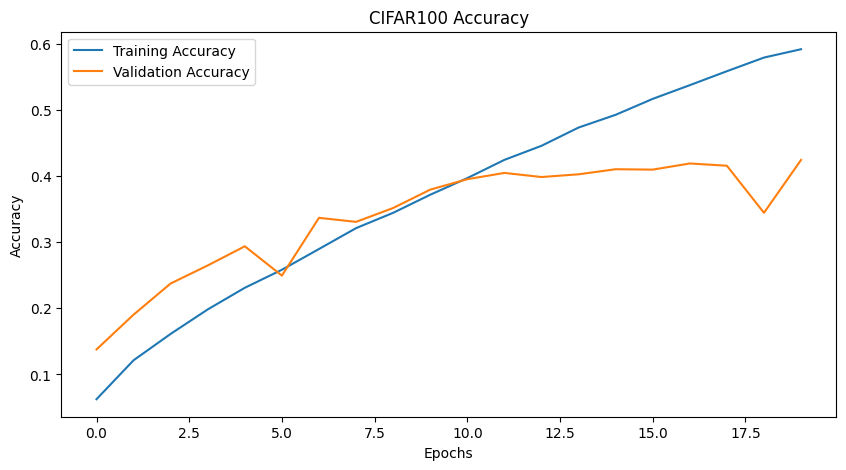

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CIFAR100 Accuracy')
plt.legend()

plt.show()

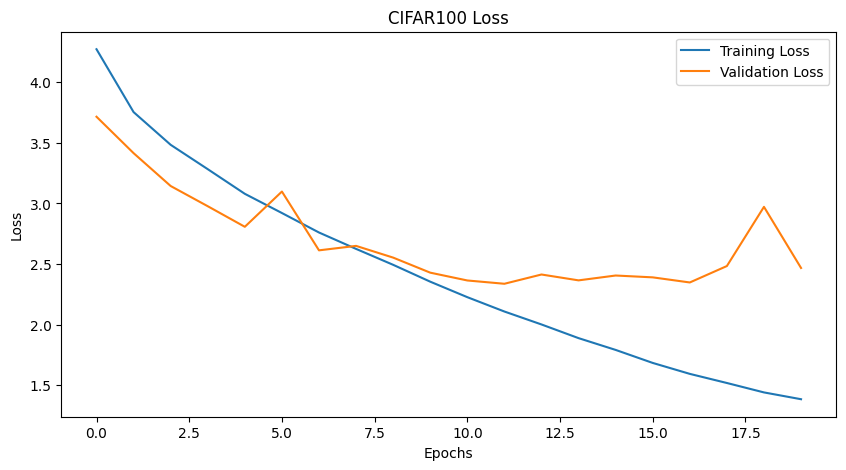

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CIFAR100 Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 764ms/step


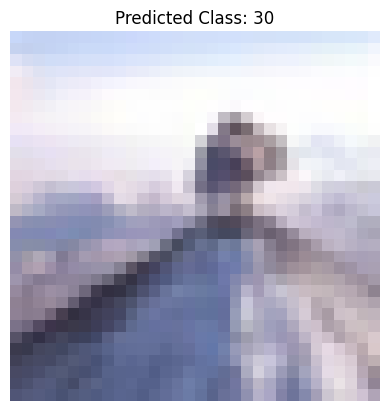

In [ ]:
sample = X_test[0]

prediction = model.predict(
    sample.reshape(1,32,32,3)
)

predicted_class = np.argmax(prediction)

plt.imshow(sample)
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()

In [ ]:
fine_labels = [
'apple','aquarium_fish','baby','bear','beaver',
'bed','bee','beetle','bicycle','bottle',
'bowl','boy','bridge','bus','butterfly',
'camel','can','castle','caterpillar','cattle',
'chair','chimpanzee','clock','cloud','cockroach',
'couch','crab','crocodile','cup','dinosaur',
'dolphin','elephant','flatfish','forest','fox',
'girl','hamster','house','kangaroo','keyboard',
'lamp','lawn_mower','leopard','lion','lizard',
'lobster','man','maple_tree','motorcycle','mountain',
'mouse','mushroom','oak_tree','orange','orchid',
'otter','palm_tree','pear','pickup_truck','pine_tree',
'plain','plate','poppy','porcupine','possum',
'rabbit','raccoon','ray','road','rocket',
'rose','sea','seal','shark','shrew',
'skunk','skyscraper','snail','snake','spider',
'squirrel','streetcar','sunflower','sweet_pepper','table',
'tank','telephone','television','tiger','tractor',
'train','trout','tulip','turtle','wardrobe',
'whale','willow_tree','wolf','woman','worm'
]

In [ ]:
predicted_class = np.argmax(prediction)

print("Predicted:",
      fine_labels[predicted_class])

Predicted: dolphin


Saving WhatsApp Image 2026-06-05 at 6.05.08 PM.jpeg to WhatsApp Image 2026-06-05 at 6.05.08 PM.jpeg


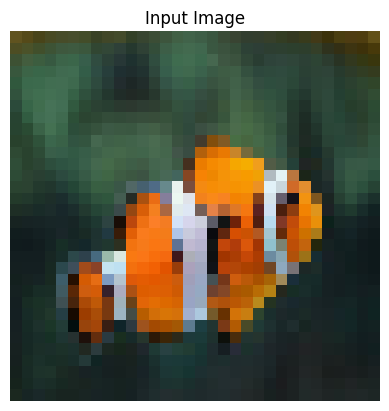

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Class: butterfly
Confidence: 70.185814 %


In [ ]:
from google.colab import files
import cv2

uploaded = files.upload()

img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img = cv2.resize(img, (32,32))

plt.imshow(img)
plt.title("Input Image")
plt.axis('off')
plt.show()

img = img / 255.0
img = img.reshape(1,32,32,3)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      fine_labels[predicted_class])

print("Confidence:",
      np.max(prediction)*100,
      "%")